In [1]:
!pip install numpy

In [2]:
import numpy as np
print(np.__version__)

2.3.5


In [3]:
!pip install pandas

In [4]:
import pandas as pd
print(pd.__version__)

2.3.3


In [5]:
!pip install matplotlib

In [6]:
import matplotlib.pyplot as plt
print("Matplotlib installed successfully")

Matplotlib installed successfully


In [7]:
!pip install seaborn

In [8]:
import seaborn as sns
print("Seaborn installed successfully")

Seaborn installed successfully


In [9]:
!pip install scikit-learn

In [10]:
import sklearn
print(sklearn.__version__)

1.7.2


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_excel("california_housing.xlsx")
df.head() #display 1st few rows of data 

,MedInc,HouseAge,AveRooms,AveOccup,Latitude,Longitude,Price
0,4.2525,47,4.26,2.44,37.713728,-118.452621,2.4134
1,8.8792,27,5.84,2.42,39.294299,-124.397350,4.7488
2,1.9588,52,3.39,2.93,38.226252,-119.646573,1.4196
3,4.8396,33,5.66,2.07,37.676390,-117.270542,3.2447
4,2.0294,47,3.20,2.86,36.524721,-124.051451,1.0343


In [4]:
#display basic information about the dataset
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MedInc     1000 non-null   float64
 1   HouseAge   1000 non-null   int64  
 2   AveRooms   1000 non-null   float64
 3   AveOccup   1000 non-null   float64
 4   Latitude   1000 non-null   float64
 5   Longitude  1000 non-null   float64
 6   Price      1000 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 54.8 KB


In [5]:
#summary statistics of dataset
df.describe()

,MedInc,HouseAge,AveRooms,AveOccup,Latitude,Longitude,Price
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,4.971686,26.609000,5.115840,3.16795,37.211255,-119.284230,2.463351
std,2.484065,14.887167,1.497249,0.98274,2.762070,3.050900,1.070338
min,0.943200,1.000000,2.000000,1.16000,32.505187,-124.496253,0.437400
25%,3.142775,13.000000,4.000000,2.48750,34.852328,-121.896814,1.665525
50%,4.449900,27.000000,4.985000,3.01000,37.072564,-119.201228,2.250900
75%,6.135850,39.000000,6.022500,3.65000,39.503973,-116.563399,3.083825
max,15.000000,52.000000,11.640000,8.05000,41.998181,-114.315029,5.000000


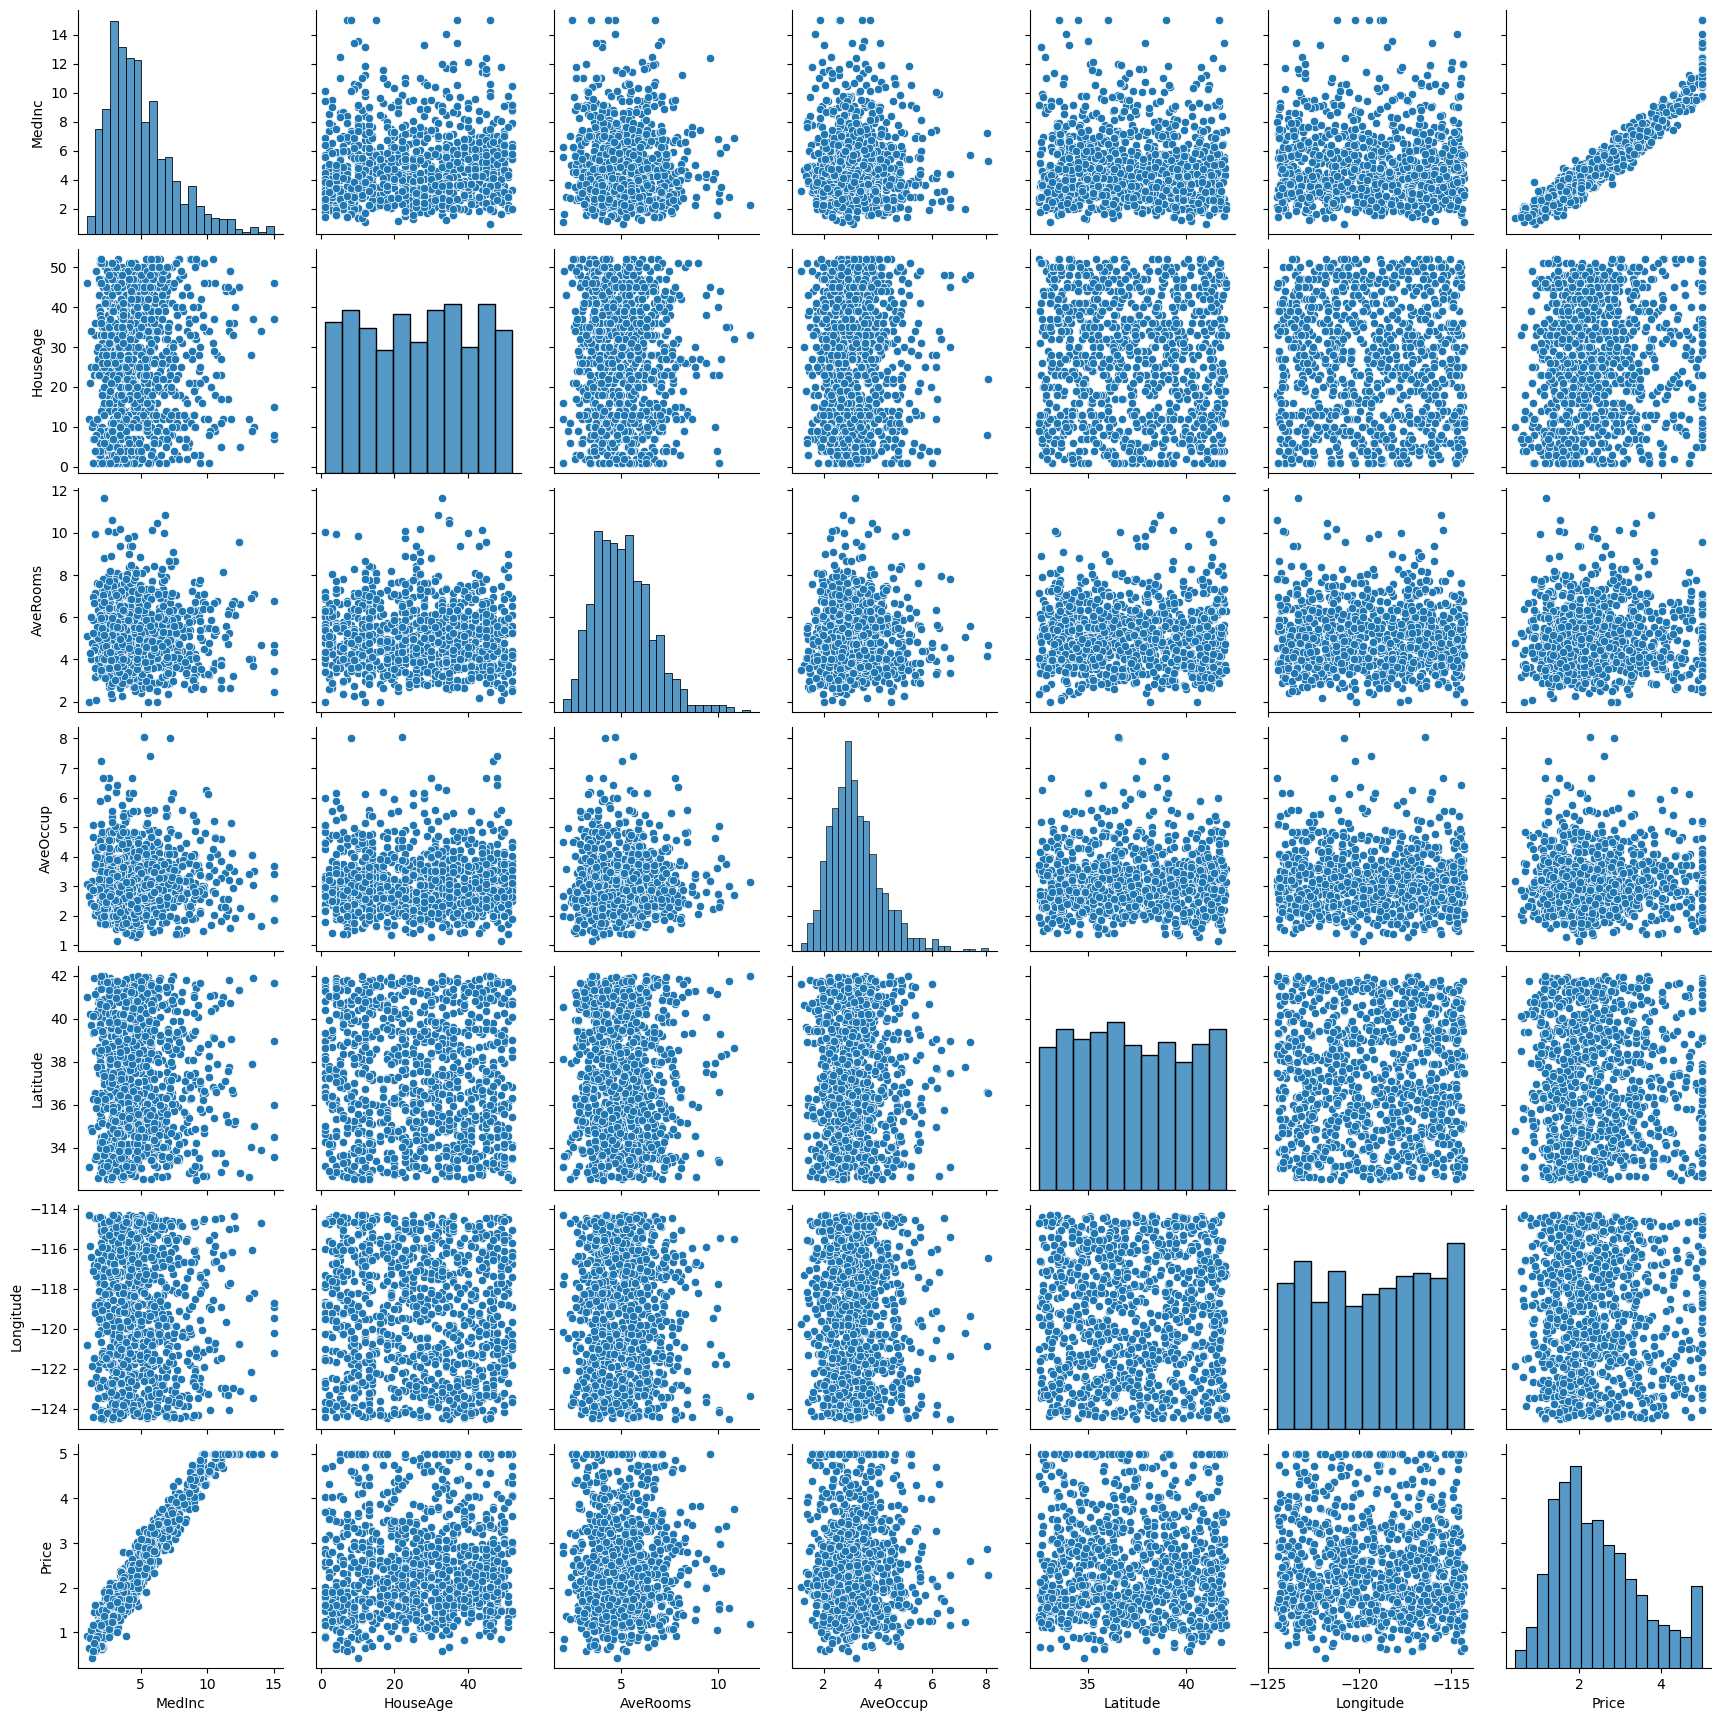

In [15]:
#pairplot to visualize relationships between variables
sns.pairplot(df)
plt.show()

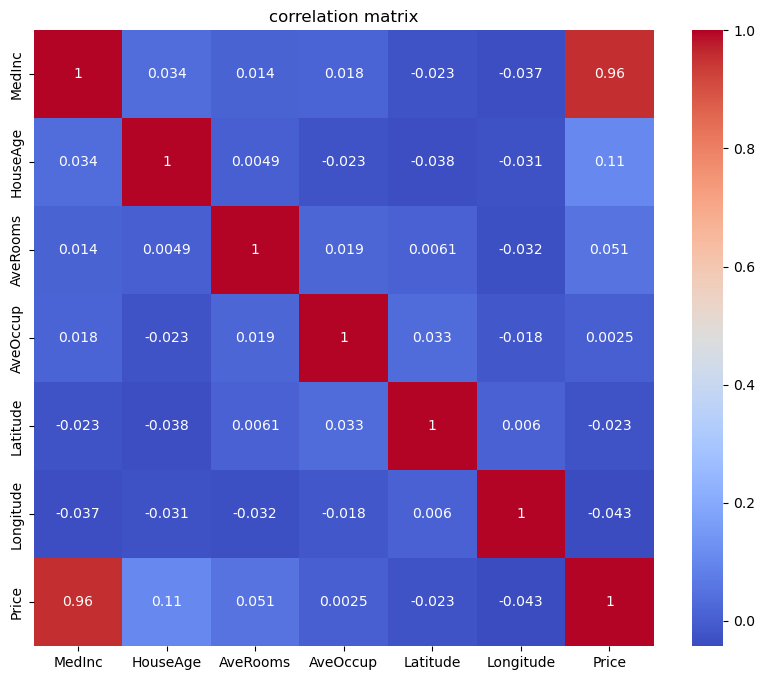

In [15]:
#correlation matrix
correlation_matrix=df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

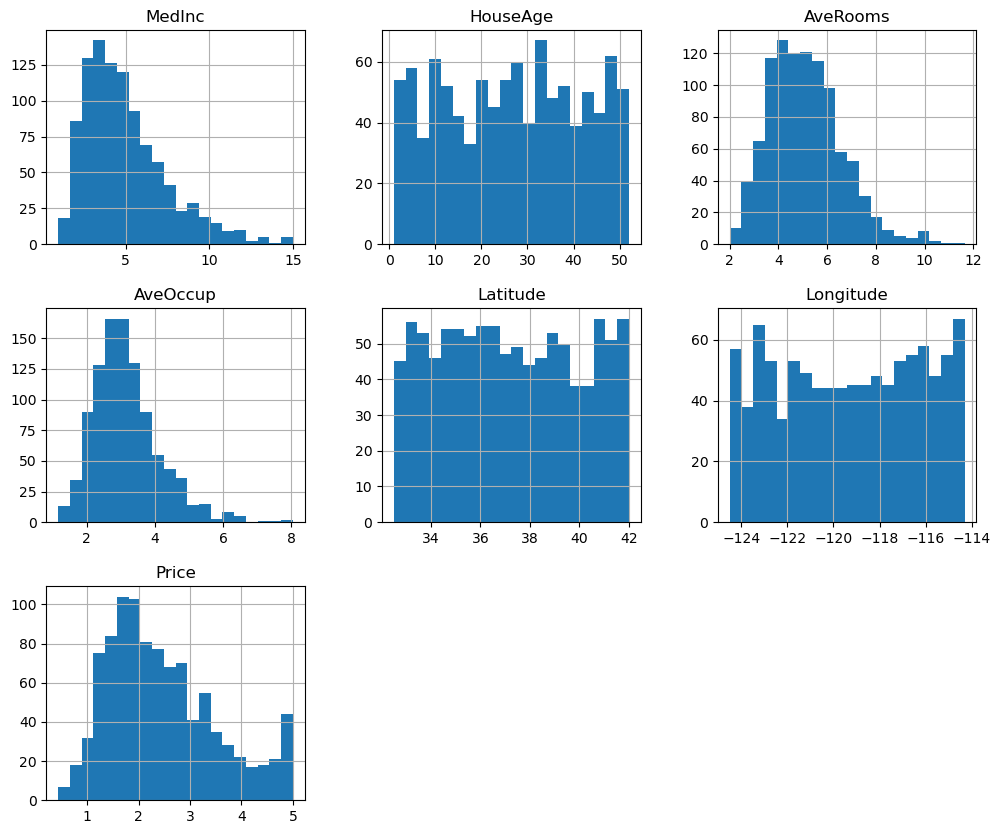

In [17]:
#Histohram of infividual features
df.hist(figsize=(12,10),bins=20)
plt.show()

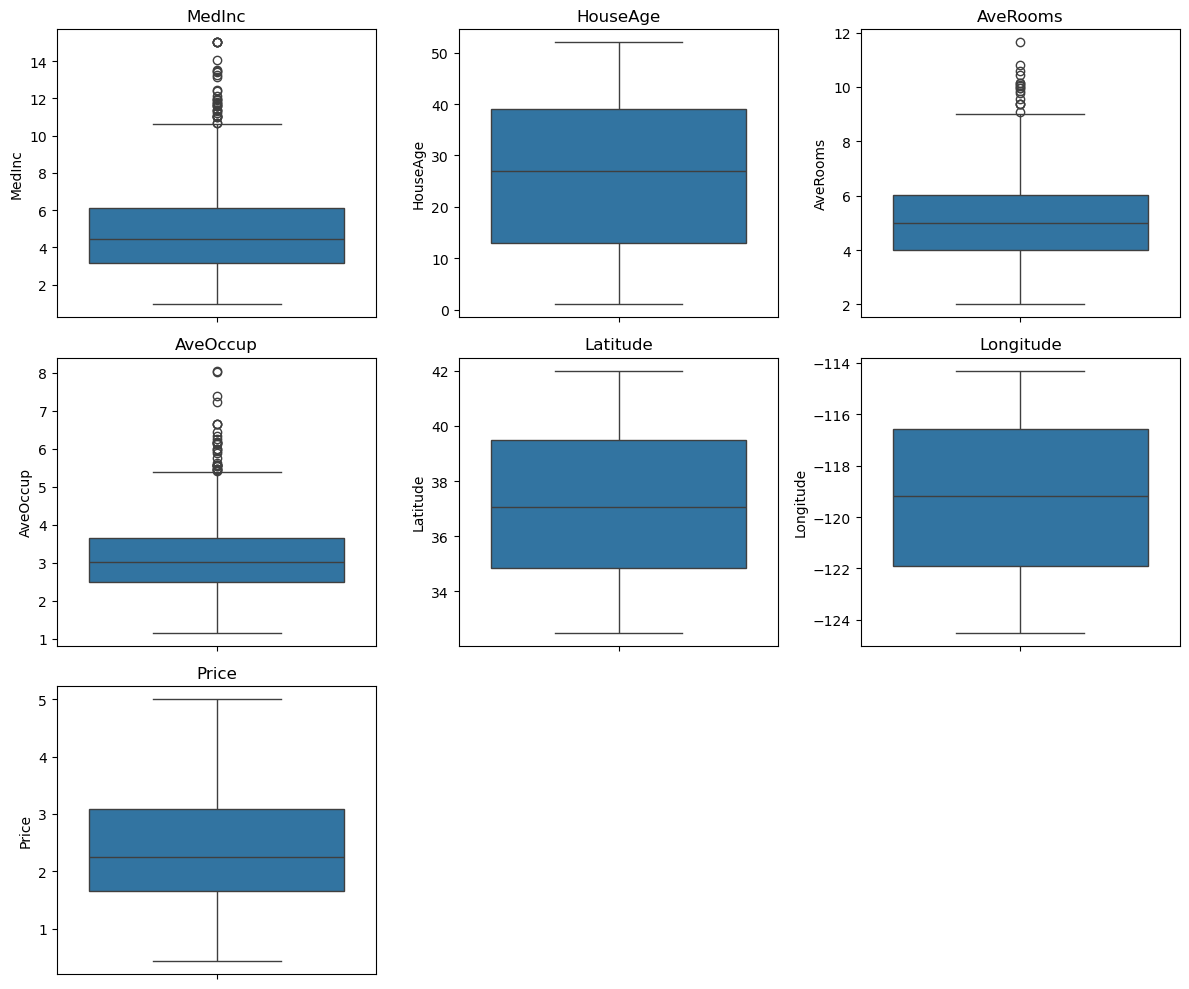

In [18]:
# Box plot to check for outliers
plt.figure(figsize=(12,10))

for i, column in enumerate(df.columns):

    # df.columns → gets all column names from dataset
    # enumerate() → gives:
    # i = index number
    # column = column name
    #
    # Example:
    # i   column
    # 0   Age
    # 1   Income
    # 2   Price

    plt.subplot(3,3,i+1)

    # 3,3 means:
    # 3 rows
    # 3 columns
    # Total = 9 plots
    # i+1 → tells where to place current plot

    sns.boxplot(df[column])   # This creates boxplot for each column
    plt.title(column)

plt.tight_layout()   # Prevents graphs from overlapping
plt.show()

# SIMPLE LINEAR REGRESSION

In [7]:
#define the targert and predicator varible
X=df[['MedInc']]# predicator= using this we will be predicting price
y=df['Price'] #target varible

In [8]:
#split data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


#test_size = 0.2
#Means:
#80% → Training data
#20% → Testing data

#Example:
#If dataset = 100 rows
#Train = 80 rows

#-------------------------------

#random_state = 42
#This makes your results reproducible
#Meaning:
#Every time you run code
#You get same split


In [9]:
#create and train the model

simple_model=LinearRegression()
# Creates Linear Regression model
# simple_model is just a variable name
# You can name it anything (like model, lr, etc.)
simple_model.fit(X_train,y_train)
                                   #This line:
                                   #Trains the model
                                   #Uses training data
                                   #Learns relationship between X and y
#Meaning:
#X_train → Input data
#y_train → Output data

#Model learns:
#y=m*x+c
#Price = m × MedInc + b

#(Linear Regression equation)   

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
#predictions
y_pred=simple_model.predict(X_test)
   # simple_model → Your trained Linear Regression model
   # predict() → Function used to make predictions     || Here: Model uses what it learned
   # X_test → Test input data                          || Predicts values for new unseen data (X_test)
   # y_pred → Predicted output values

   # Simple Meaning:
   # "Use the trained model to predict values for test data"


#evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

Mean Squared Error: 0.1034645043151356
R2 Score: 0.90751004018839


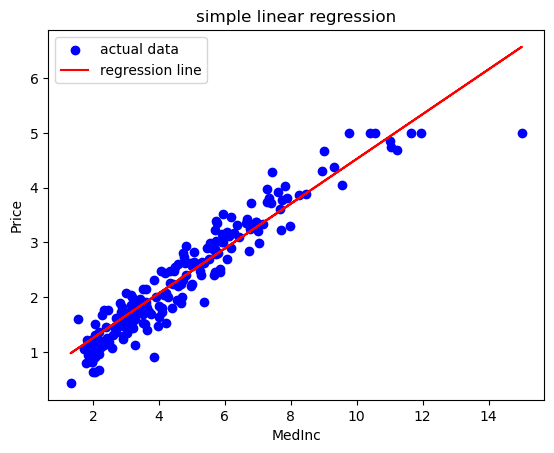

In [11]:
#plot the regression line
plt.scatter(X_test,y_test,color='blue',label='actual data')
plt.plot(X_test,y_pred,color='red',label='regression line')
plt.xlabel('MedInc')
plt.ylabel('Price')
plt.title('simple linear regression')
plt.legend()
#Legend
#plt.legend()
#Shows:
#Blue = Actual data
#Red = Regression line
plt.show()


In [12]:
#assuming the model has already been trained and the revelant librarues have veen imported 
#This means:Model is already trained using: REMEMBER :simple_model.fit(X_train, y_train)

#input MedInc value from the user
medinc_value=float(input("enter the medinc value:"))

#convert the input to a 2D array fro the model
medinc_value_array=np.array([[medinc_value]]) #why we convert to 2d array because the sklearn expect an 2d input 
                                              #Before 5.2 || After: [[5.2]]
#predict the house price using the trained model
predicted_price = simple_model.predict(medinc_value_array) #What happens:Model uses trained data and Predicts house price

#output of  the preduction
price = predicted_price[0] #gets the first value 
                         #price = predicted_price[0]
                         #Why:
                             #Prediction returns array
                             #We extract first value
print("The predicted house price for MedInc value of", medinc_value, "is:", price)

enter the medinc value: 4.8


The predicted house price for MedInc value of 4.8 is: 2.3995284046422336


# MULTIPLE LINEAR REGRESSION


In [14]:
#define the multiple predictor
# Define multiple predictors
X_multi = df[['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude']]
y_multi = df['Price']


### or you can also write this as 
X = df.drop('Price', axis=1)
y_multi = df['Price']

In [26]:
# Split the dataset into training and testing sets
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

In [27]:
#create and train the model
multi_model=LinearRegression()
multi_model.fit(X_train_multi,y_train_multi)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
#prediction

y_pred_multi=multi_model.predict(X_test_multi)

#evaluate the model
mse = mean_squared_error(y_test_multi, y_pred_multi)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test_multi, y_pred_multi)
print("R2 Score:", r2)

Mean Squared Error: 0.0951823110813603
R2 Score: 0.9149137360202542


In [29]:
#display the coefficent of the model
coefficients = pd.DataFrame(multi_model.coef_,X_multi.columns,columns=['Coefficient'])
print(coefficients)

           Coefficient
MedInc        0.406989
HouseAge      0.005055
AveRooms      0.031216
AveOccup     -0.016038
Latitude      0.000693
Longitude    -0.002674
